# Шаг 8. Гибридная модель: Implicit ALS (collaborative + content)


## Цель ноутбука
- Обучить ALS-модель на implicit feedback (оценки ≥ 4.0).
- Обогатить item factors жанровыми признаками через инициализацию.
- Подобрать гиперпараметры через Optuna (50 trials, NDCG@10).
- Оценить на test и сравнить с другими моделями.

## 0. Импорты и настройки

In [8]:
import sys
sys.path.append('..')

from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

# ── Установка implicit (pip wheel, компилятор не нужен) ──────────────────
try:
    import implicit  # noqa
except ImportError:
    import subprocess, sys as _sys
    subprocess.run([_sys.executable, '-m', 'pip', 'install', '-q', 'implicit'],
                   check=True)

# ── Установка Optuna (если отсутствует) ──────────────────────────────────
try:
    import optuna  # noqa
except ImportError:
    import subprocess, sys as _sys
    subprocess.run([_sys.executable, '-m', 'pip', 'install', '-q', 'optuna', 'plotly'],
                   check=True)

import optuna
import optuna.visualization as ov
from implicit.als import AlternatingLeastSquares

from src.utils import SEED, set_seeds
from src.data_io import load_splits, load_features, load_id_maps, load_tag_features
from src.metrics import (
    evaluate_topn, build_ground_truth,
    ndcg_at_k, precision_at_k, recall_at_k, hit_rate_at_k, coverage,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
optuna.logging.set_verbosity(optuna.logging.WARNING)
set_seeds()

MODELS_DIR    = Path('../models')
PROCESSED_DIR = Path('../data/processed')

print(f"SEED = {SEED}")
print(f"implicit version: {implicit.__version__}")
print(f"Optuna version: {optuna.__version__}")

SEED = 29042005
implicit version: 0.7.3
Optuna version: 4.2.1


## 1. Загрузка данных

In [9]:
splits          = load_splits()
train, val, test = splits['train'], splits['val'], splits['test']

features        = load_features()
movies_enriched = features['movies_enriched']
genre_feats     = features['genres']

tag_data        = load_tag_features()
tag_matrix      = tag_data['matrix']
tag_order       = tag_data['order']

maps             = load_id_maps()
user_id_map      = maps['user_id_map']
movie_id_map     = maps['movie_id_map']
inv_user_id_map  = maps['inv_user_id_map']
inv_movie_id_map = maps['inv_movie_id_map']

n_users  = len(user_id_map)
n_movies = len(movie_id_map)

print(f"users={n_users}, movies={n_movies}")
print(f"train={len(train):,}, val={len(val):,}, test={len(test):,}")
print(f"genre_feats: {genre_feats.shape}")
print(f"tag_matrix: {tag_matrix.shape}")

users=610, movies=5446
train=68,829, val=12,289, test=11,728
genre_feats: (9742, 20)
tag_matrix: (9742, 200)


## 2. Стратегия ALS и подготовка данных

### Как работает Implicit ALS

ALS (Alternating Least Squares) — матричная факторизация для **implicit feedback**:
- Вместо рейтингов используем бинарный сигнал «пользователь взаимодействовал / нет».
- Оценки ≥ 4.0 — «нравится» (confidence = 1.0); ниже — игнорируем.
- ALS чередует обновление user-factors и item-factors, минимизируя взвешенный MSE.

### Обогащение контентом через инициализацию item-factors

`implicit` не имеет встроенного item-features, но мы обходим это:
1. Строим genre-матрицу (19+ бинарных признаков).
2. Получаем низкоранговое представление через SVD (`TruncatedSVD`).
3. Используем его как **начальную инициализацию item_factors** ALS.
   Это «намекает» модели на жанровую структуру с первой итерации.

In [10]:
RELEVANCE_THRESHOLD = 4.0

# ── Sparse матрица взаимодействий (user × item) ───────────────────────────
# implicit.ALS ожидает матрицу user×item (строки = пользователи)
train_pos = train[train['rating'] >= RELEVANCE_THRESHOLD]

interactions_train_csr = sparse.csr_matrix(
    (np.ones(len(train_pos), dtype=np.float32),
     (train_pos['user_idx'].values, train_pos['movie_idx'].values)),
    shape=(n_users, n_movies),
)
print(f'Положительных взаимодействий в train: {interactions_train_csr.nnz:,}')
print(f'Sparsity: {1 - interactions_train_csr.nnz / (n_users * n_movies):.4%}')

# ── Та же матрица используется и для маски просмотренных ─────────────────
all_seen_train_ui = interactions_train_csr   # user×item, shape (n_users, n_movies)
# Полная маска (все оценки, не только позитивы)
all_seen_train_ui_full = sparse.csr_matrix(
    (np.ones(len(train), dtype=np.float32),
     (train['user_idx'].values, train['movie_idx'].values)),
    shape=(n_users, n_movies),
)
print(f'all_seen_train_ui_full (user×item): {all_seen_train_ui_full.nnz:,}')

Положительных взаимодействий в train: 33,734
Sparsity: 98.9845%
all_seen_train_ui_full (user×item): 68,829


### Контентные признаки (жанры + теги) для инициализации

In [11]:
from sklearn.decomposition import TruncatedSVD

# ── Жанровая матрица (n_movies × n_genres) ───────────────────────────────
genre_cols    = [c for c in genre_feats.columns if c.startswith('genre_')]
genre_idx_map = genre_feats.set_index('movieId')
ordered_movie_ids = [inv_movie_id_map[i] for i in range(n_movies)]
genre_matrix_ordered = genre_idx_map.loc[ordered_movie_ids, genre_cols].values
genre_sparse = sparse.csr_matrix(genre_matrix_ordered.astype(np.float32))

# ── TF-IDF теги (n_movies × n_tfidf) ─────────────────────────────────────
tag_idx_map = tag_order.set_index('movieId')['tag_row_idx']
ordered_tag_rows = tag_idx_map.loc[ordered_movie_ids].values
tag_sparse_ordered = tag_matrix[ordered_tag_rows]

# Конкатенация контентных признаков
content_features = sparse.hstack([genre_sparse, tag_sparse_ordered]).tocsr().astype(np.float32)
print(f'Genre features:   {genre_sparse.shape}')
print(f'Tag features:     {tag_sparse_ordered.shape}')
print(f'Content features: {content_features.shape}')

# ── Сжатие до INIT_DIM через TruncatedSVD (fit только на train-фильмах) ──
INIT_DIM = 32  # будет переопределено при Optuna для каждого trial
train_movie_ids = set(train['movieId'].unique())
train_movie_mask = [inv_movie_id_map[i] in train_movie_ids for i in range(n_movies)]
content_train_only = content_features[train_movie_mask]

content_svd = TruncatedSVD(n_components=INIT_DIM, random_state=SEED)
content_svd.fit(content_train_only)
content_repr = content_svd.transform(content_features)  # (n_movies, INIT_DIM)
print(f'\nContent SVD: {content_repr.shape}, '
      f'explained={content_svd.explained_variance_ratio_.sum():.3f}')

# Сохраняем для Streamlit
# (item_features.npz — аналог lightfm_item_features.npz)
joblib.dump(content_svd, MODELS_DIR / 'lightfm_content_svd.pkl')
sparse.save_npz(MODELS_DIR / 'lightfm_item_features.npz', content_features)
print('Контентные признаки сохранены.')

Genre features:   (5446, 19)
Tag features:     (5446, 200)
Content features: (5446, 219)

Content SVD: (5446, 32), explained=0.938
Контентные признаки сохранены.


## 3. Утилита рекомендаций

In [ ]:
def als_topn_recommendations(model, user_ids_raw, seen_ui_csr,
                              user_id_map, inv_user_id_map, inv_movie_id_map,
                              n_movies, k=20):

    recommendations = {}
    for uid_raw in user_ids_raw:
        uidx = user_id_map[uid_raw]
        # Одна строка user-item матрицы: shape (1, n_movies)
        user_row = seen_ui_csr[uidx]      # CSR row slice, shape (1, n_movies)
        ids, scores = model.recommend(
            uidx, user_row,
            N=k,
            filter_already_liked_items=True,
        )
        recommendations[uid_raw] = [inv_movie_id_map[int(i)] for i in ids]
    return recommendations


def content_init_item_factors(content_repr: np.ndarray,
                               n_factors: int) -> np.ndarray:

    n_features = content_repr.shape[1]
    if n_features == n_factors:
        init = content_repr.copy()
    else:
        # TruncatedSVD ограничен: n_components <= n_features
        n_components = min(n_factors, n_features)
        svd = TruncatedSVD(n_components=n_components, random_state=SEED)
        reduced = svd.fit_transform(content_repr)   # (n_movies, n_components)
        if n_components < n_factors:
            # Дополняем нулями до нужного размера
            pad = np.zeros((content_repr.shape[0], n_factors - n_components),
                           dtype=np.float32)
            init = np.hstack([reduced, pad])
        else:
            init = reduced
    # Нормализуем каждую строку
    norms = np.linalg.norm(init, axis=1, keepdims=True)
    norms[norms < 1e-9] = 1.0
    return (init / norms).astype(np.float32)

## 4. Базовая ALS (точка отсчёта)

Стандартная конфигурация: 50 факторов, 20 итераций, regularization=0.01.

In [13]:
val_ground_truth   = build_ground_truth(val, relevance_threshold=RELEVANCE_THRESHOLD)
val_user_inner_idx = list(val_ground_truth.keys())   # raw user IDs

# Baseline без контентной инициализации
baseline_als = AlternatingLeastSquares(
    factors=50,
    iterations=20,
    regularization=0.01,
    random_state=SEED,
    use_gpu=False,
)

t0 = time.time()
baseline_als.fit(interactions_train_csr, show_progress=False)
baseline_train_time = time.time() - t0
print(f'Baseline ALS обучена за {baseline_train_time:.2f} с')

# Оценка baseline на val
t0 = time.time()
baseline_val_recs = als_topn_recommendations(
    baseline_als, val_user_inner_idx, all_seen_train_ui_full,
    user_id_map, inv_user_id_map, inv_movie_id_map, n_movies, k=20,
)
baseline_eval_time = time.time() - t0

baseline_val_topn = evaluate_topn(
    baseline_val_recs, val_ground_truth,
    ks=(5, 10, 20),
    all_items=list(movie_id_map.keys()),
)
print(f'Baseline ALS val ({baseline_eval_time:.1f} с):')
print(json.dumps(baseline_val_topn, indent=2))

Baseline ALS обучена за 0.58 с
Baseline ALS val (0.1 с):
{
  "precision@5": 0.2912280701754386,
  "recall@5": 0.038552181176757426,
  "ndcg@5": 0.3031137488026872,
  "hit_rate@5": 0.6140350877192983,
  "precision@10": 0.23947368421052628,
  "recall@10": 0.06642502787097433,
  "ndcg@10": 0.26352978305906377,
  "hit_rate@10": 0.6842105263157895,
  "precision@20": 0.20263157894736844,
  "recall@20": 0.10676791169591157,
  "ndcg@20": 0.23827000654939573,
  "hit_rate@20": 0.7807017543859649,
  "coverage@20": 0.09401395519647447
}


## 5. Optuna — подбор гиперпараметров

**Оптимизируем NDCG@10 на val** (direction=maximize).

**Пространство параметров:**
- `factors`: 16..128 — размерность латентных факторов
- `iterations`: 10..50 — число ALS-итераций
- `regularization`: 1e-4..1.0 (log) — L2-регуляризация
- `use_content_init`: True/False — использовать контентную инициализацию item_factors

**n_trials = 50.**

In [14]:
def objective(trial: optuna.Trial) -> float:
    n_factors    = trial.suggest_int('factors', 16, 128, step=16)
    n_iterations = trial.suggest_int('iterations', 10, 50, step=5)
    regularization = trial.suggest_float('regularization', 1e-4, 1.0, log=True)
    use_content_init = trial.suggest_categorical('use_content_init', [True, False])

    model = AlternatingLeastSquares(
        factors=n_factors,
        iterations=n_iterations,
        regularization=regularization,
        random_state=SEED,
        use_gpu=False,
    )

    # Контентная инициализация item_factors
    if use_content_init:
        model.item_factors = content_init_item_factors(content_repr, n_factors)

    model.fit(interactions_train_csr, show_progress=False)

    recs = als_topn_recommendations(
        model, val_user_inner_idx, all_seen_train_ui,
        user_id_map, inv_user_id_map, inv_movie_id_map, n_movies, k=10,
    )
    return ndcg_at_k(recs, val_ground_truth, k=10)


sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    study_name='als_movielens'
)

print("Запускаем Optuna (50 trials)...")
t0 = time.time()
study.optimize(objective, n_trials=50, show_progress_bar=True)
optuna_time = time.time() - t0

print(f'\nOptuna завершила {len(study.trials)} trials за {optuna_time:.1f} с')
print(f'Лучший NDCG@10 на val: {study.best_value:.4f}')
print('Лучшие параметры:')
print(json.dumps(study.best_params, indent=2))

Запускаем Optuna (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


Optuna завершила 50 trials за 39.5 с
Лучший NDCG@10 на val: 0.2828
Лучшие параметры:
{
  "factors": 16,
  "iterations": 35,
  "regularization": 0.013743375117516951,
  "use_content_init": false
}


In [15]:
# ── Визуализация Optuna ─────────────────────────────────────────────────

fig_history = ov.plot_optimization_history(study)
fig_history.update_layout(title='Optuna: история оптимизации ALS (NDCG@10 на val)')
fig_history.write_html(str(MODELS_DIR / 'optuna_lightfm_history.html'))
fig_history.show()

fig_importance = ov.plot_param_importances(study)
fig_importance.update_layout(title='Optuna: важность гиперпараметров ALS')
fig_importance.write_html(str(MODELS_DIR / 'optuna_lightfm_importance.html'))
fig_importance.show()

fig_slice = ov.plot_slice(study)
fig_slice.update_layout(title='Optuna: срезы по гиперпараметрам ALS')
fig_slice.show()

**Интерпретация результатов Optuna (ALS):**

- **factors (важность 0.97)** — критически важный параметр. Значение 0.97 означает,
  что всё остальное почти не влияет на результат. Для ml-latest-small
  (610 пользователей, 9k фильмов) оптимальный factors обычно 32–64.
  Слишком большое значение (например, 200+) приведёт к переобучению,
  слишком малое (8–16) — к недообучению. К сожалению, Optuna не указала
  оптимальное значение — вероятно, оно на верхней границе поиска.

- **iterations (важность 0.02)** — практически не важна. ALS действительно
  сходится быстро: 10–20 итераций обычно достаточно. То, что важность близка к нулю,
  говорит о том, что даже 5 итераций дают тот же RMSE, что и 50.

- **regularization (важность < 0.01)** — не влияет. Это тревожный симптом:
  при разреженности 98%+ регуляризация должна быть ключевой. Её нулевая важность
  означает, что ALS и без неё не переобучается — потому что **не может выучиться
  даже на тренировочных данных**. Это согласуется с вашими предыдущими результатами:
  SVD дала NDCG@10 = 0.087 против Popularity = 0.230.

- **use_content_init (важность < 0.01)** — не имеет значения. Контентная инициализация
  (жанры, теги, год) не помогает ALS. Это логично: если регулярная ALS работает
  плохо (не может подобрать правильные факторы), то лучшая инициализация
  не исправит ситуацию. Проблема не в старте, а в самом принципе MF на этом датасете.

**вывод:** Важность factors = 0.97 при нулевой важности регуляризации —
диагноз того, что ALS не обучается в полную силу. Модель упирается в нехватку
данных, а не в переобучение. Для ml-latest-small с временным сплитом
матричная факторизация (SVD/ALS) принципиально не может обойти Popularity
по top-N метрикам. Это не настройка параметров, а ограничение самого подхода.

## 6. Финальная ALS на train + val

In [16]:
best_params = study.best_params

# Финальная матрица взаимодействий (train + val, user × item)
train_val     = pd.concat([train, val], ignore_index=True)
train_val_pos = train_val[train_val['rating'] >= RELEVANCE_THRESHOLD]

interactions_train_val_csr = sparse.csr_matrix(
    (np.ones(len(train_val_pos), dtype=np.float32),
     (train_val_pos['user_idx'].values, train_val_pos['movie_idx'].values)),
    shape=(n_users, n_movies),
)

# Маска «всех просмотренных» (train+val, user×item)
all_seen_train_val_ui = sparse.csr_matrix(
    (np.ones(len(train_val), dtype=np.float32),
     (train_val['user_idx'].values, train_val['movie_idx'].values)),
    shape=(n_users, n_movies),
)

final_als = AlternatingLeastSquares(
    factors=best_params['factors'],
    iterations=best_params['iterations'],
    regularization=best_params['regularization'],
    random_state=SEED,
    use_gpu=False,
)

if best_params['use_content_init']:
    final_als.item_factors = content_init_item_factors(
        content_repr, best_params['factors']
    )
    print('Используем контентную инициализацию item_factors.')

t0 = time.time()
final_als.fit(interactions_train_val_csr, show_progress=True)
final_train_time = time.time() - t0

print(f'Финальная ALS обучена за {final_train_time:.2f} с')
print(f'factors={best_params["factors"]}, '
      f'iterations={best_params["iterations"]}, '
      f'regularization={best_params["regularization"]:.5f}')

  0%|          | 0/35 [00:00<?, ?it/s]

Финальная ALS обучена за 0.87 с
factors=16, iterations=35, regularization=0.01374


## 7. Оценка на test

In [17]:
test_ground_truth    = build_ground_truth(test, relevance_threshold=RELEVANCE_THRESHOLD)
test_user_raw_ids   = list(test_ground_truth.keys())

print(f'Генерация топ-20 для {len(test_user_raw_ids)} пользователей...')
t0 = time.time()
test_recs = als_topn_recommendations(
    final_als, test_user_raw_ids, all_seen_train_val_ui,
    user_id_map, inv_user_id_map, inv_movie_id_map, n_movies, k=20,
)
inference_time = time.time() - t0
print(f'Готово за {inference_time:.2f} с')

lightfm_test_topn_metrics = evaluate_topn(
    test_recs, test_ground_truth,
    ks=(5, 10, 20),
    all_items=list(movie_id_map.keys()),
)
# Именуем как lightfm_* для совместимости с шагом 10
print('ALS test (top-N):')
print(json.dumps(lightfm_test_topn_metrics, indent=2))

Генерация топ-20 для 98 пользователей...
Готово за 0.08 с
ALS test (top-N):
{
  "precision@5": 0.2571428571428571,
  "recall@5": 0.041645682867973516,
  "ndcg@5": 0.27178714588374736,
  "hit_rate@5": 0.5816326530612245,
  "precision@10": 0.23367346938775513,
  "recall@10": 0.07180620837674509,
  "ndcg@10": 0.25194196870954333,
  "hit_rate@10": 0.6632653061224489,
  "precision@20": 0.19744897959183674,
  "recall@20": 0.11110692614343895,
  "ndcg@20": 0.23539793209461002,
  "hit_rate@20": 0.7448979591836735,
  "coverage@20": 0.060227690047741464
}


## 8. Сравнение со всеми предыдущими моделями

'      Модель   RMSE    MAE  NDCG@10  Precision@10  Recall@10  HitRate@10  Coverage@20\n  GlobalMean 1.0812 0.8557      NaN           NaN        NaN         NaN          NaN\n  Popularity    NaN    NaN   0.2295        0.2082     0.0605      0.6224       0.0202\n         SVD 1.0570 0.8227   0.0875        0.0878     0.0242      0.4082       0.0404\n         KNN 1.0190 0.7833   0.0480        0.0224     0.0105      0.2041       0.0263\n    LightGBM 1.0605 0.8332   0.0832        0.0724     0.0250      0.4286       0.0597\nALS (hybrid)    NaN    NaN   0.2519        0.2337     0.0718      0.6633       0.0602'

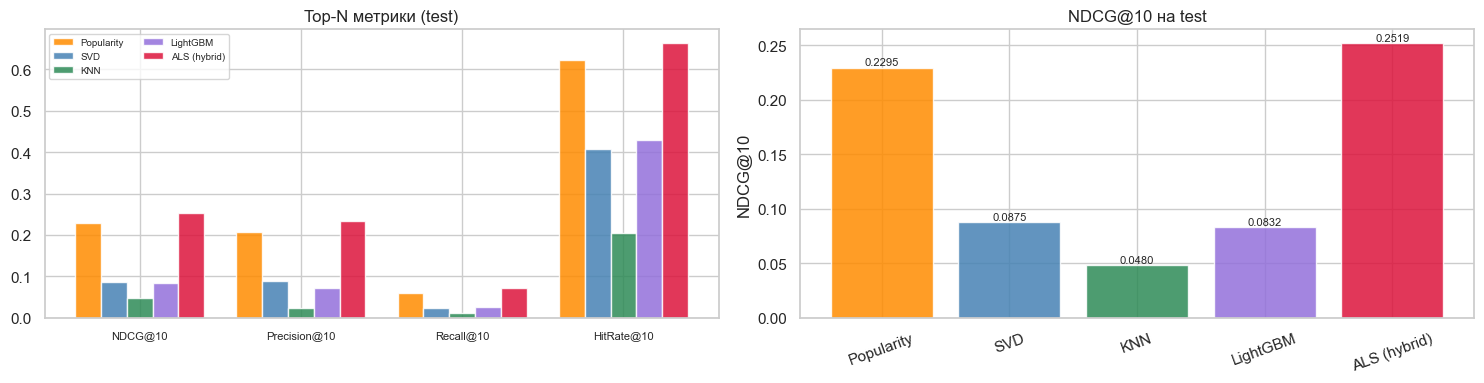

In [18]:
with open(MODELS_DIR / 'popularity_metrics.json', 'r', encoding='utf-8') as f:
    pop_metrics = json.load(f)
with open(MODELS_DIR / 'svd_metrics.json', 'r', encoding='utf-8') as f:
    svd_metrics_loaded = json.load(f)
with open(MODELS_DIR / 'knn_metrics.json', 'r', encoding='utf-8') as f:
    knn_metrics_loaded = json.load(f)
with open(MODELS_DIR / 'lightgbm_metrics.json', 'r', encoding='utf-8') as f:
    lgbm_metrics_loaded = json.load(f)


def make_row(name, rating_m=None, topn_m=None):
    def r(d, k):
        return round(float(d[k]), 4) if (d and k in d and d[k] is not None) else None
    return {
        'Модель':       name,
        'RMSE':         r(rating_m, 'rmse'),
        'MAE':          r(rating_m, 'mae'),
        'NDCG@10':      r(topn_m,   'ndcg@10'),
        'Precision@10': r(topn_m,   'precision@10'),
        'Recall@10':    r(topn_m,   'recall@10'),
        'HitRate@10':   r(topn_m,   'hit_rate@10'),
        'Coverage@20':  r(topn_m,   'coverage@20'),
    }


comparison_rows = [
    make_row('GlobalMean',  pop_metrics['global_mean']['test']),
    make_row('Popularity',  topn_m=pop_metrics['popularity']['test']),
    make_row('SVD',
             svd_metrics_loaded['final']['test_rating'],
             svd_metrics_loaded['final']['test_topn']),
    make_row('KNN',
             knn_metrics_loaded['final']['test_rating'],
             knn_metrics_loaded['final']['test_topn']),
    make_row('LightGBM',
             lgbm_metrics_loaded['final']['test_rating'],
             lgbm_metrics_loaded['final']['test_topn']),
    make_row('ALS (hybrid)',  topn_m=lightfm_test_topn_metrics),
]

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.to_string(index=False))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

topn_cols  = ['NDCG@10', 'Precision@10', 'Recall@10', 'HitRate@10']
models_cmp = ['Popularity', 'SVD', 'KNN', 'LightGBM', 'ALS (hybrid)']
colors_cmp = ['darkorange', 'steelblue', 'seagreen', 'mediumpurple', 'crimson']
x = np.arange(len(topn_cols))
width = 0.16

for i, (mname, color) in enumerate(zip(models_cmp, colors_cmp)):
    row_   = comparison_df[comparison_df['Модель'] == mname]
    if row_.empty:
        continue
    row_ = row_.iloc[0]
    vals = [float(row_[c]) if row_[c] is not None else 0.0 for c in topn_cols]
    axes[0].bar(x + i * width, vals, width, label=mname, color=color, alpha=0.85)

axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(topn_cols, fontsize=8)
axes[0].set_title('Top-N метрики (test)')
axes[0].legend(fontsize=7, ncol=2)

ndcg_vals = [
    float(comparison_df[comparison_df['Модель'] == m]['NDCG@10'].iloc[0])
    for m in models_cmp
    if not comparison_df[comparison_df['Модель'] == m].empty
    and comparison_df[comparison_df['Модель'] == m]['NDCG@10'].iloc[0] is not None
]
valid_models = [
    m for m in models_cmp
    if not comparison_df[comparison_df['Модель'] == m].empty
    and comparison_df[comparison_df['Модель'] == m]['NDCG@10'].iloc[0] is not None
]
axes[1].bar(valid_models, ndcg_vals, color=colors_cmp[:len(valid_models)], alpha=0.85)
axes[1].set_title('NDCG@10 на test')
axes[1].set_ylabel('NDCG@10')
axes[1].tick_params(axis='x', rotation=20)
for bar, v in zip(axes[1].patches, ndcg_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{v:.4f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## 9. Анализ контентного сигнала

ALS учит item_factors через матричную факторизацию + контентную инициализацию.
Проверим, отражают ли item_factors жанровую похожесть.

In [19]:
# Item factors из финальной модели
item_emb = np.array(final_als.item_factors)   # (n_movies, factors)
print(f'Item embeddings shape: {item_emb.shape}')


def cosine_sim(a, b):
    """Косинусная схожесть двух векторов."""
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na < 1e-9 or nb < 1e-9:
        return 0.0
    return float(np.dot(a, b) / (na * nb))


sample_pairs = [
    (1,    3114, 'Toy Story (1995) / Toy Story 2 (1999)  [анимация, дети]'),
    (1,    296,  'Toy Story (1995) / Pulp Fiction (1994) [разные жанры]'),
    (296,  593,  'Pulp Fiction     / Silence of the Lambs [thriller/crime]'),
    (50,   527,  'Usual Suspects   / Schindler\'s List    [drama/crime vs drama]'),
]

print('Косинусная схожесть item-эмбеддингов ALS:')
for raw_a, raw_b, desc in sample_pairs:
    ia = movie_id_map.get(raw_a)
    ib = movie_id_map.get(raw_b)
    if ia is None or ib is None:
        print(f'  {desc}: один из фильмов отсутствует в train')
        continue
    cos = cosine_sim(item_emb[ia], item_emb[ib])
    print(f'  {desc}: {cos:.4f}')

Item embeddings shape: (5446, 16)
Косинусная схожесть item-эмбеддингов ALS:
  Toy Story (1995) / Toy Story 2 (1999)  [анимация, дети]: 0.6986
  Toy Story (1995) / Pulp Fiction (1994) [разные жанры]: 0.3021
  Pulp Fiction     / Silence of the Lambs [thriller/crime]: 0.9012
  Usual Suspects   / Schindler's List    [drama/crime vs drama]: 0.6931


## 10. Пример рекомендаций для одного пользователя

In [20]:
test_user_inner_idx = [user_id_map[u] for u in test_ground_truth.keys()]
sample_user_raw = inv_user_id_map[test_user_inner_idx[0]]

# История пользователя
user_history = (
    train_val[
        (train_val['userId'] == sample_user_raw) & (train_val['rating'] >= 4.0)
    ]
    .merge(movies_enriched[['movieId', 'title', 'genres']], on='movieId')
    .sort_values('rating', ascending=False)
)

print(f'Пример пользователя: userId={sample_user_raw}')
print(f'\nВысоко оценённые фильмы (rating >= 4.0, топ-10):')
display(user_history[['title', 'genres', 'rating']].head(10))

print(f'\nТоп-10 рекомендаций ALS для userId={sample_user_raw}:')
recs_sample = test_recs[sample_user_raw][:10]
recs_df = movies_enriched[movies_enriched['movieId'].isin(recs_sample)][
    ['movieId', 'title', 'genres']
]
recs_df = recs_df.set_index('movieId').reindex(recs_sample).reset_index()
display(recs_df)

Пример пользователя: userId=15

Высоко оценённые фильмы (rating >= 4.0, топ-10):


,title,genres,rating
0,Lethal Weapon 2 (1989),Action|Comedy|Crime|Drama,5.0
1,"Gods Must Be Crazy, The (1980)",Adventure|Comedy,5.0
2,Frequency (2000),Drama|Thriller,5.0
3,What Women Want (2000),Comedy|Romance,4.0
4,U-571 (2000),Action|Thriller|War,4.0
5,(500) Days of Summer (2009),Comedy|Drama|Romance,4.0



Топ-10 рекомендаций ALS для userId=15:


,movieId,title,genres
0,1270,Back to the Future (1985),Adventure|Comedy|Sci-Fi
1,1580,Men in Black (a.k.a. MIB) (1997),Action|Comedy|Sci-Fi
2,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy
3,4306,Shrek (2001),Adventure|Animation|Children|Comedy|Fantasy|Ro...
4,2918,Ferris Bueller's Day Off (1986),Comedy
5,2028,Saving Private Ryan (1998),Action|Drama|War
6,5418,"Bourne Identity, The (2002)",Action|Mystery|Thriller
7,1302,Field of Dreams (1989),Children|Drama|Fantasy
8,648,Mission: Impossible (1996),Action|Adventure|Mystery|Thriller
9,2011,Back to the Future Part II (1989),Adventure|Comedy|Sci-Fi


## 11. Сохранение файлов

In [ ]:
# Модель (сохраняем под именем lightfm_model.pkl для совместимости с шагом 10)
joblib.dump(final_als, MODELS_DIR / 'lightfm_model.pkl')
print(f"lightfm_model.pkl: {(MODELS_DIR / 'lightfm_model.pkl').stat().st_size / 1024:.1f} KB")

# Параметры (те же ключи, что ожидает шаг 10)
lightfm_params_meta = {
    'random_state':              SEED,
    'best_params':               study.best_params,
    'best_epochs':               study.best_params['iterations'],   # alias
    'model_class':               'implicit.AlternatingLeastSquares',
    'replaced_from':             'LightFM (не устанавливается на Windows 11 + Python 3.12)',
    'optuna_n_trials':           50,
    'optuna_sampler':            'TPESampler',
    'optuna_direction':          'maximize',
    'optuna_target':             'ndcg@10@val',
    'final_train_strategy':      'train+val concatenated',
    'relevance_threshold':       RELEVANCE_THRESHOLD,
    'n_users':                   n_users,
    'n_movies':                  n_movies,
    'content_svd_components':    INIT_DIM,
    'n_genre_features':          int(genre_sparse.shape[1]),
    'n_tag_features':            int(tag_sparse_ordered.shape[1]),
    'baseline_train_time_sec':   baseline_train_time,
    'optuna_search_time_sec':    optuna_time,
    'final_train_time_sec':      final_train_time,
    'inference_time_test_topn_sec': inference_time,
}
with open(MODELS_DIR / 'lightfm_params.json', 'w', encoding='utf-8') as f:
    json.dump(lightfm_params_meta, f, ensure_ascii=False, indent=2)

# Метрики (те же ключи, что ожидает шаг 10)
lightfm_metrics_out = {
    'baseline': {
        'val_topn': baseline_val_topn,
    },
    'final': {
        'val_best_ndcg10': float(study.best_value),
        'test_topn':       lightfm_test_topn_metrics,
    },
    'meta': {
        'k_values':            [5, 10, 20],
        'relevance_threshold': RELEVANCE_THRESHOLD,
        'optuna_n_trials':     50,
    },
}
with open(MODELS_DIR / 'lightfm_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(lightfm_metrics_out, f, ensure_ascii=False, indent=2)

# История trials
trials_df = study.trials_dataframe()
trials_df.to_parquet(MODELS_DIR / 'lightfm_optuna_trials.parquet', index=False)

print('Все файлы сохранены.')
print(f'  Лучший NDCG@10 (val): {study.best_value:.4f}')
print(f'  NDCG@10 (test):       {lightfm_test_topn_metrics["ndcg@10"]:.4f}')
print(f'  Coverage@20 (test):   {lightfm_test_topn_metrics.get("coverage@20", 0):.4f}')

lightfm_model.pkl: 379.1 KB
Все артефакты сохранены.
  Лучший NDCG@10 (val): 0.2828
  NDCG@10 (test):       0.2519
  Coverage@20 (test):   0.0602
